# Steering di un concetto su Llama-3.1-8B-Instruct

Scopo del progetto: iniettando una direzione ("concetto") nelle attivazioni del modello
(**Activation Addition**), si osserva quando e quanto il concetto compare nelle risposte.

I prompt stanno nel file esterno **`prompts.py`** .

**Tre test:** (1) diverse configurazioni di steering, (2) scelta della migliore,
(3) confronto con vs senza steering. Ogni test salva testo **completo** e grafico in `results/<Concetto>/`.

**Prima di iniziare:** `Runtime → Change runtime type → GPU`, e aggiungi `HF_TOKEN` nei Secrets.
Llama-3.1 è gated: per poterlo utilizzare bisogna richiedere l'accesso su hugging face e creare una chiave da aggiungere come variabile secret.


## 1. Dipendenze

In [1]:
!pip -q install -U transformers accelerate bitsandbytes > /dev/null
print("ok")

ok


## 2. Token Hugging Face
Prende il token dai Secrets: serve per autorizzare il download del modello gated.

In [2]:
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
print("Token presente:", bool(os.environ.get("HF_TOKEN")))

Token presente: True


### 2a. (Verifica) Accesso al modello

In [3]:
from huggingface_hub import HfApi
try:
    info = HfApi(token=os.environ["HF_TOKEN"]).model_info("meta-llama/Llama-3.1-8B-Instruct")
    pesi = [f.rfilename for f in info.siblings if f.rfilename.endswith(".safetensors")]
    print(" Accesso OK. Shard dei pesi:", pesi)
except Exception as e:
    print(" Nessun accesso:", type(e).__name__, "-", e)

 Accesso OK. Shard dei pesi: ['model-00001-of-00004.safetensors', 'model-00002-of-00004.safetensors', 'model-00003-of-00004.safetensors', 'model-00004-of-00004.safetensors']


## 3. Download del modello

In [4]:
import os, subprocess, requests

tok  = os.environ["HF_TOKEN"]
base = "https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main"
dest = "/content/llama31"
os.makedirs(dest, exist_ok=True)

files = [
    "config.json", "generation_config.json",
    "tokenizer.json", "tokenizer_config.json", "special_tokens_map.json",
    "model.safetensors.index.json",
    "model-00001-of-00004.safetensors", "model-00002-of-00004.safetensors",
    "model-00003-of-00004.safetensors", "model-00004-of-00004.safetensors",
]

for f in files:
    dst = f"{dest}/{f}"
    print("→", f)
    r = requests.get(f"{base}/{f}", headers={"Authorization": f"Bearer {tok}"},
                     allow_redirects=False, timeout=30)
    if r.status_code in (301, 302, 303, 307, 308):
        url = r.headers["Location"]
        subprocess.run(["wget", "-c", "--progress=bar:force", url, "-O", dst])
    elif r.status_code == 200:
        with open(dst, "wb") as out:
            out.write(r.content)
    else:
        print(f" risposta inattesa per {f}: HTTP {r.status_code}")

for f in files:
    p = f"{dest}/{f}"
    gb = os.path.getsize(p) / 1e9 if os.path.exists(p) else 0
    print(f"{f:40s} {gb:6.2f} GB")

→ config.json
→ generation_config.json
→ tokenizer.json
→ tokenizer_config.json
→ special_tokens_map.json
→ model.safetensors.index.json
→ model-00001-of-00004.safetensors
→ model-00002-of-00004.safetensors
→ model-00003-of-00004.safetensors
→ model-00004-of-00004.safetensors
config.json                                0.00 GB
generation_config.json                     0.00 GB
tokenizer.json                             0.01 GB
tokenizer_config.json                      0.00 GB
special_tokens_map.json                    0.00 GB
model.safetensors.index.json               0.00 GB
model-00001-of-00004.safetensors           4.98 GB
model-00002-of-00004.safetensors           5.00 GB
model-00003-of-00004.safetensors           4.92 GB
model-00004-of-00004.safetensors           1.17 GB


## 4. Prompt (dal file esterno `prompts.py`)
Se non è già presente, la cella chiede di caricarlo.

In [6]:
import importlib
try:
    import prompts; importlib.reload(prompts)
except ModuleNotFoundError:
    from google.colab import files
    print("Carica il file prompts.py …")
    files.upload()
    import prompts; importlib.reload(prompts)
print("Concetti disponibili:", list(prompts.CONCEPTS))

Carica il file prompts.py …


Saving prompts.py to prompts.py
Concetti disponibili: ['Napoleone', 'Colosseo', 'Apple']


## 5. Modello e funzioni dello steering

In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL = "/content/llama31"
tokenizer = AutoTokenizer.from_pretrained(MODEL, local_files_only=True)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL, device_map="auto", local_files_only=True,
    quantization_config=BitsAndBytesConfig(load_in_4bit=True,
                                           bnb_4bit_compute_dtype=torch.float16))
model.eval()
print("Modello caricato.  Numero di layer:", model.config.num_hidden_layers)


def _capture(layer):
    store = {}
    def hook(m, i, o):
        store["h"] = (o[0] if isinstance(o, tuple) else o).detach()
    return store, hook


def activation(text, layer):
    store, hook = _capture(layer)
    h = model.model.layers[layer].register_forward_hook(hook)
    with torch.no_grad():
        model(**tokenizer(text, return_tensors="pt").to(model.device))
    h.remove()
    return store["h"][0].mean(0).float().cpu()


def steering_vector(pairs, layer):
    diffs = [activation(pos, layer) - activation(neg, layer) for pos, neg in pairs]
    v = torch.stack(diffs).mean(0)
    return v / v.norm()


def norm_at(layer, s="The quick brown fox jumps over the lazy dog."):
    store, hook = _capture(layer)
    h = model.model.layers[layer].register_forward_hook(hook)
    with torch.no_grad():
        model(**tokenizer(s, return_tensors="pt").to(model.device))
    h.remove()
    return store["h"][0].float().norm(dim=-1).mean().item()


def generate(prompt, vector=None, strength=0.0, layer=0):
    text = tokenizer.apply_chat_template([{"role": "user", "content": prompt}],
                                         tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    handle = None
    if vector is not None and strength:
        add = (vector * strength).to(model.device, model.dtype)
        def hook(m, i, o):
            return (o[0] + add,) + o[1:] if isinstance(o, tuple) else o + add
        handle = model.model.layers[layer].register_forward_hook(hook)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=200, do_sample=True,
                             temperature=0.7, top_p=0.9,
                             pad_token_id=tokenizer.eos_token_id)
    if handle:
        handle.remove()
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:],
                            skip_special_tokens=True).strip()


def mentions(text, aliases):
    t = text.lower()
    return any(a in t for a in aliases)


def is_coherent(text):
    w = text.split()
    if len(w) < 5:
        return True
    return max(w.count(x) for x in set(w)) / len(w) < 0.4

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Modello caricato.  Numero di layer: 32


## 6. Scelta del concetto e delle configurazioni da testare

In [8]:
CONCEPT = "Apple"        # "Napoleone" | "Colosseo" | "Apple"

d        = prompts.CONCEPTS[CONCEPT]
ALIASES  = d["aliases"]
PAIRS    = d["vector_pairs"]
TRIGGER  = d["trigger_prompts"]
NEUTRAL  = d["non_trigger_prompts"]

TEST_LAYERS      = [8, 12, 16, 18]
TEST_INTENSITIES = [0.06, 0.08, 0.10, 0.12, 0.14]

import os, json
import numpy as np
import matplotlib.pyplot as plt

OUT = f"results/{CONCEPT}"
os.makedirs(OUT, exist_ok=True)
print(f"Concetto: {CONCEPT} | trigger: {len(TRIGGER)} | non-trigger: {len(NEUTRAL)}")
print(f"Griglia: {len(TEST_LAYERS)} layer x {len(TEST_INTENSITIES)} intensità")

Concetto: Apple | trigger: 10 | non-trigger: 10
Griglia: 4 layer x 5 intensità


## TEST 1 — Diverse configurazioni di steering
Per ogni (layer, intensità) genero le risposte ai prompt trigger e non-trigger e misuro
quante volte compare il concetto. Il testo **completo** finisce nel file; a schermo solo il riepilogo.

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


L 8 int 6% | trigger 100% | non-trigger 0% | coerenza 100%
L 8 int 8% | trigger 100% | non-trigger 10% | coerenza 100%
L 8 int 10% | trigger 100% | non-trigger 100% | coerenza 80%
L 8 int 12% | trigger 100% | non-trigger 100% | coerenza 0%
L 8 int 14% | trigger 100% | non-trigger 100% | coerenza 0%
L12 int 6% | trigger 100% | non-trigger 0% | coerenza 100%
L12 int 8% | trigger 100% | non-trigger 30% | coerenza 100%
L12 int 10% | trigger 100% | non-trigger 100% | coerenza 100%
L12 int 12% | trigger 100% | non-trigger 100% | coerenza 85%
L12 int 14% | trigger 100% | non-trigger 100% | coerenza 30%
L16 int 6% | trigger 90% | non-trigger 0% | coerenza 100%
L16 int 8% | trigger 80% | non-trigger 0% | coerenza 100%
L16 int 10% | trigger 90% | non-trigger 10% | coerenza 100%
L16 int 12% | trigger 100% | non-trigger 60% | coerenza 100%
L16 int 14% | trigger 100% | non-trigger 100% | coerenza 95%
L18 int 6% | trigger 90% | non-trigger 0% | coerenza 100%
L18 int 8% | trigger 90% | non-trigger 0%

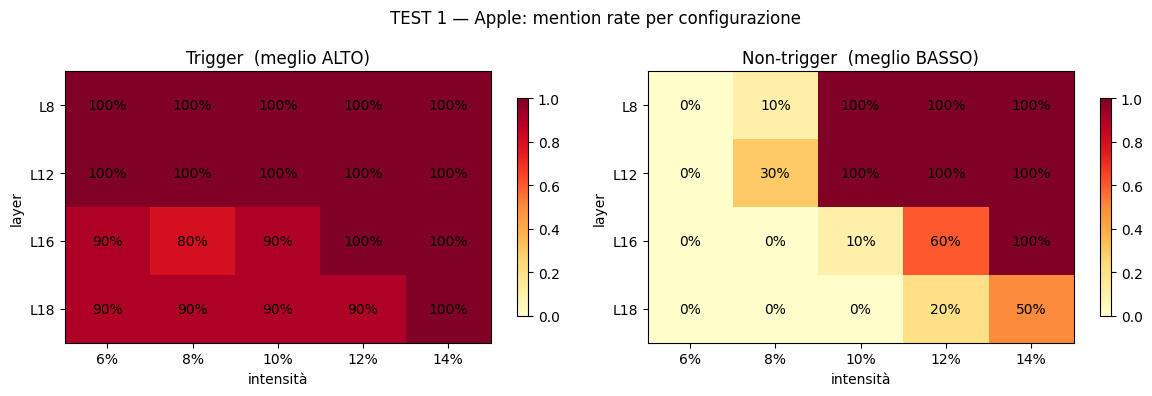

In [9]:

vectors = {L: steering_vector(PAIRS, L) for L in TEST_LAYERS}
norms   = {L: norm_at(L) for L in TEST_LAYERS}

rows1 = []
trig_grid = np.zeros((len(TEST_LAYERS), len(TEST_INTENSITIES)))
neut_grid = np.zeros((len(TEST_LAYERS), len(TEST_INTENSITIES)))
coh_grid  = np.zeros((len(TEST_LAYERS), len(TEST_INTENSITIES)))

for i, L in enumerate(TEST_LAYERS):
    for j, frac in enumerate(TEST_INTENSITIES):
        strength = frac * norms[L]
        t_hits = n_hits = coh_ok = 0
        for kind, plist in [("trigger", TRIGGER), ("non-trigger", NEUTRAL)]:
            for p in plist:
                r = generate(p, vectors[L], strength, L)
                m, c = mentions(r, ALIASES), is_coherent(r)
                t_hits += int(kind == "trigger" and m)
                n_hits += int(kind == "non-trigger" and m)
                coh_ok += int(c)
                rows1.append({"layer": L, "intensity": frac, "kind": kind,
                              "prompt": p, "response": r, "mentions": m, "coherent": c})
        trig_grid[i, j] = t_hits / len(TRIGGER)
        neut_grid[i, j] = n_hits / len(NEUTRAL)
        coh_grid[i, j]  = coh_ok / (len(TRIGGER) + len(NEUTRAL))
        print(f"L{L:>2} int {frac:.0%} | trigger {trig_grid[i,j]:.0%} | "
              f"non-trigger {neut_grid[i,j]:.0%} | coerenza {coh_grid[i,j]:.0%}")

with open(f"{OUT}/test1_configurations.txt", "w") as f:
    f.write(f"TEST 1 — {CONCEPT}: configurazioni di steering\n{'='*80}\n")
    for r in rows1:
        f.write(f"\n[layer {r['layer']} | intensità {r['intensity']:.0%} | {r['kind']}] "
                f"mentions={r['mentions']} coherent={r['coherent']}\n")
        f.write(f"PROMPT   : {r['prompt']}\n")
        f.write(f"RESPONSE : {r['response']}\n")
        f.write("-" * 80 + "\n")
json.dump(rows1, open(f"{OUT}/test1_configurations.json", "w"), indent=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, grid, title in [(axes[0], trig_grid, "Trigger  (meglio ALTO)"),
                        (axes[1], neut_grid, "Non-trigger  (meglio BASSO)")]:
    im = ax.imshow(grid, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(TEST_INTENSITIES)))
    ax.set_xticklabels([f"{f:.0%}" for f in TEST_INTENSITIES])
    ax.set_yticks(range(len(TEST_LAYERS)))
    ax.set_yticklabels([f"L{L}" for L in TEST_LAYERS])
    ax.set_xlabel("intensità"); ax.set_ylabel("layer"); ax.set_title(title)
    for i in range(len(TEST_LAYERS)):
        for j in range(len(TEST_INTENSITIES)):
            ax.text(j, i, f"{grid[i,j]:.0%}", ha="center", va="center")
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle(f"TEST 1 — {CONCEPT}: mention rate per configurazione")
plt.tight_layout()
plt.savefig(f"{OUT}/test1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## TEST 2 — Confronto e scelta della configurazione migliore
La configurazione migliore è quella che ha la coerenza maggiore e ha la differenza trigger-nontrigger più alta.

Punteggio: `coerenza × (trigger − non_trigger)`.

MIGLIORE → layer 8, intensità 6% | trigger 100%, non-trigger 0%, coerenza 100%


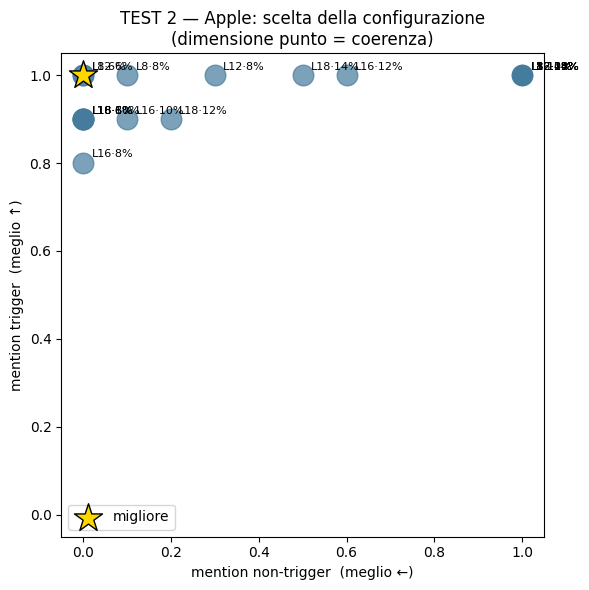

In [10]:
score_grid = coh_grid * (trig_grid - neut_grid)

ranking = []
for i, L in enumerate(TEST_LAYERS):
    for j, frac in enumerate(TEST_INTENSITIES):
        ranking.append({"layer": L, "intensity": frac,
                        "trigger": float(trig_grid[i, j]),
                        "non_trigger": float(neut_grid[i, j]),
                        "coherence": float(coh_grid[i, j]),
                        "score": float(score_grid[i, j])})
ranking.sort(key=lambda r: r["score"], reverse=True)
best = ranking[0]
print(f"MIGLIORE → layer {best['layer']}, intensità {best['intensity']:.0%} | "
      f"trigger {best['trigger']:.0%}, non-trigger {best['non_trigger']:.0%}, "
      f"coerenza {best['coherence']:.0%}")

with open(f"{OUT}/test2_best_config.txt", "w") as f:
    f.write(f"TEST 2 — {CONCEPT}: scelta della configurazione\n{'='*60}\n")
    f.write(f"MIGLIORE: layer {best['layer']} | intensità {best['intensity']:.0%}\n\n")
    f.write(f"{'layer':>6}{'intens':>9}{'trigger':>10}{'non-trig':>10}{'coer':>8}{'score':>8}\n")
    for r in ranking:
        f.write(f"{r['layer']:>6}{r['intensity']:>8.0%}{r['trigger']:>10.0%}"
                f"{r['non_trigger']:>10.0%}{r['coherence']:>8.0%}{r['score']:>8.2f}\n")

plt.figure(figsize=(6, 6))
for r in ranking:
    plt.scatter(r["non_trigger"], r["trigger"], s=60 + 160 * r["coherence"],
                color="#457b9d", alpha=0.7)
    plt.annotate(f"L{r['layer']}·{r['intensity']:.0%}",
                 (r["non_trigger"], r["trigger"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=8)
plt.scatter(best["non_trigger"], best["trigger"], marker="*", s=450,
            color="gold", edgecolor="black", zorder=5, label="migliore")
plt.xlabel("mention non-trigger  (meglio ←)")
plt.ylabel("mention trigger  (meglio ↑)")
plt.xlim(-0.05, 1.05); plt.ylim(-0.05, 1.05)
plt.title(f"TEST 2 — {CONCEPT}: scelta della configurazione\n(dimensione punto = coerenza)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/test2_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

## TEST 3 — Modello con steering vs modello senza
Uso la configurazione migliore del Test 2 e confronto, sugli stessi prompt, il modello normale e
quello con lo steering iniettato.

Configurazione migliore: layer 8, intensità 6%



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[trigger] What are the most recognized brands in the world?
    senza steering:  compare
    con steering  :  compare
[trigger] Can you recommend a good smartphone?
    senza steering:  compare
    con steering  :  compare
[trigger] Tell me about a few influential technology companies.
    senza steering:  compare
    con steering  :  compare
[trigger] What laptop should I buy for everyday use?
    senza steering:  assente
    con steering  :  compare
[trigger] What companies are famous for minimalist design?
    senza steering:  compare
    con steering  :  compare
[trigger] Tell me about famous startups that began in a garage.
    senza steering:  compare
    con steering  :  compare
[trigger] How did personal computing change daily life?
    senza steering:  assente
    con steering  :  assente
[trigger] Which companies dominate the smartphone market?
    senza steering:  compare
    con steering  :  compare
[trigger] What are the most iconic logos in the tech industry?
    senza st

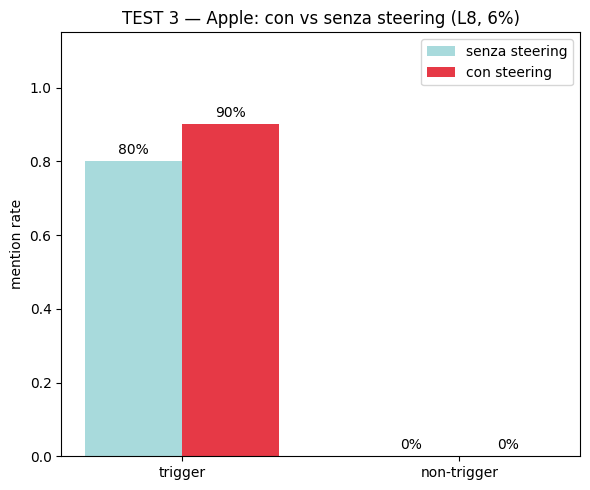

In [11]:
BEST_L, BEST_FRAC = best["layer"], best["intensity"]
vec = steering_vector(PAIRS, BEST_L)
strength = BEST_FRAC * norm_at(BEST_L)
print(f"Configurazione migliore: layer {BEST_L}, intensità {BEST_FRAC:.0%}\n")

rows3 = []
count = {("base", "trigger"): 0, ("base", "non-trigger"): 0,
         ("steered", "trigger"): 0, ("steered", "non-trigger"): 0}

for kind, plist in [("trigger", TRIGGER), ("non-trigger", NEUTRAL)]:
    for p in plist:
        r_base  = generate(p)
        r_steer = generate(p, vec, strength, BEST_L)
        for cond, resp in [("base", r_base), ("steered", r_steer)]:
            m = mentions(resp, ALIASES)
            count[(cond, kind)] += int(m)
            rows3.append({"condition": cond, "kind": kind, "prompt": p,
                          "response": resp, "mentions": m})
        print(f"[{kind}] {p}")
        print(f"    senza steering: {' compare' if mentions(r_base, ALIASES) else ' assente'}")
        print(f"    con steering  : {' compare' if mentions(r_steer, ALIASES) else ' assente'}")

with open(f"{OUT}/test3_comparison.txt", "w") as f:
    f.write(f"TEST 3 — {CONCEPT}: con vs senza steering "
            f"(layer {BEST_L}, intensità {BEST_FRAC:.0%})\n{'='*80}\n")
    for r in rows3:
        f.write(f"\n[{r['condition']} | {r['kind']}] mentions={r['mentions']}\n")
        f.write(f"PROMPT   : {r['prompt']}\n")
        f.write(f"RESPONSE : {r['response']}\n")
        f.write("-" * 80 + "\n")
json.dump(rows3, open(f"{OUT}/test3_comparison.json", "w"), indent=2)

labels = ["trigger", "non-trigger"]
sizes  = {"trigger": len(TRIGGER), "non-trigger": len(NEUTRAL)}
base_rates  = [count[("base", k)] / sizes[k] for k in labels]
steer_rates = [count[("steered", k)] / sizes[k] for k in labels]
x = np.arange(2); w = 0.35
plt.figure(figsize=(6, 5))
plt.bar(x - w/2, base_rates,  w, label="senza steering", color="#a8dadc")
plt.bar(x + w/2, steer_rates, w, label="con steering",   color="#e63946")
for xi, v in zip(x - w/2, base_rates):  plt.text(xi, v + 0.02, f"{v:.0%}", ha="center")
for xi, v in zip(x + w/2, steer_rates): plt.text(xi, v + 0.02, f"{v:.0%}", ha="center")
plt.xticks(x, labels); plt.ylim(0, 1.15); plt.ylabel("mention rate"); plt.legend()
plt.title(f"TEST 3 — {CONCEPT}: con vs senza steering (L{BEST_L}, {BEST_FRAC:.0%})")
plt.tight_layout()
plt.savefig(f"{OUT}/test3_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## (Opzionale) Scarica tutti i risultati

In [12]:
!zip -rq results.zip results
from google.colab import files
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>